In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def myPCA(X,n_components):
    X_c = X - np.mean(X, axis=0)
    U,S,VT = np.linalg.svd(X_c,full_matrices=False)
    cov = np.cov(X_c,rowvar=False)
    eigval,eigvec = np.linalg.eigh(cov)
    sortindex = np.argsort(eigval)[::-1]
    eigval = eigval[sortindex]
    eigvec = eigvec[:,sortindex]

    components = eigvec[:,:n_components]
    var_ex = eigval[:n_components]
    X_pro = X_c @ components
    return X_pro,components,var_ex

In [3]:
 df = pd.read_csv("../data/city_lifestyle_dataset.csv")
 X = df.drop(['city_name', 'country'], axis=1)

In [4]:
X = df.select_dtypes(include=[np.number]).values

In [5]:
X_pro,comp,var = myPCA(X,n_components=2)
print(f"Var explained{var}\n")

Var explained[8967629.16635253 1559194.91602561]



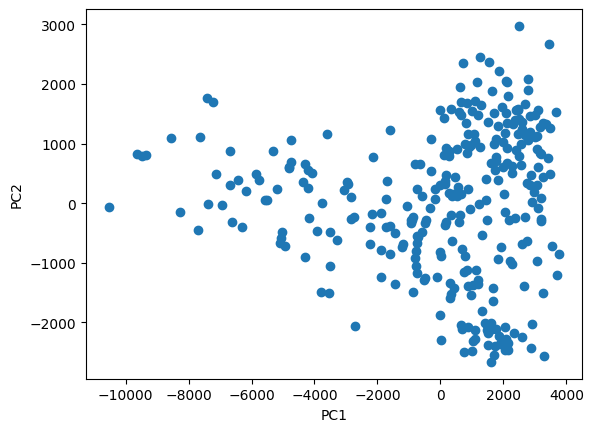

In [6]:
plt.figure()
plt.scatter(X_pro[:,0],X_pro[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [7]:
df_red = pd.DataFrame(X_pro, columns=["PC1", "PC2"])
df_red.to_csv("pca_emb_2d.csv", index=False)